In [1]:
"""
XGB_Classifier_60GeV_Holdout

Per-run holdout counterpart to XGB_Classifier_60GeV.ipynb (and the XGBoost
analogue of CNN_/MLP_Classifier_60GeV_Holdout.ipynb): entire runs are locked out
of training, then used as the test set. This is the honest measure of whether
the gradient-boosted trees generalize to runs they have never seen, vs. relying
on per-run channel-level shortcuts (dead/noisy channels, pedestal drift) that a
flat-feature model can latch onto.

Holdout runs: 577 (h/43V), 579 (h/45V), 605 (e/43V), 603 (e/45V) -- one per cell.
Pedestal stats are computed from training events only to avoid leakage.

Binary objective (binary:logistic); P(electron) via predict_proba.
"""


'\nXGB_Classifier_60GeV_Holdout\n\nPer-run holdout counterpart to XGB_Classifier_60GeV.ipynb (and the XGBoost\nanalogue of CNN_/MLP_Classifier_60GeV_Holdout.ipynb): entire runs are locked out\nof training, then used as the test set. This is the honest measure of whether\nthe gradient-boosted trees generalize to runs they have never seen, vs. relying\non per-run channel-level shortcuts (dead/noisy channels, pedestal drift) that a\nflat-feature model can latch onto.\n\nHoldout runs: 577 (h/43V), 579 (h/45V), 605 (e/43V), 603 (e/45V) -- one per cell.\nPedestal stats are computed from training events only to avoid leakage.\n\nBinary objective (binary:logistic); P(electron) via predict_proba.\n'

In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import uproot
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix


def find_project_root(marker="Data", start=None):
    """Walk up from `start` (default: cwd) until we find a directory containing `marker`."""
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' starting from {p}")

PROJECT_ROOT = find_project_root("Data")
DATA_DIR     = PROJECT_ROOT / "Data"
LABELS_CSV   = DATA_DIR / "runs.csv"
print("project root:", PROJECT_ROOT)


project root: /Users/prometheus/Documents/Python/ML_FoCal_FinalProject


In [3]:
# data loading
labels_df = pd.read_csv(LABELS_CSV)
runs_df = labels_df.query("energy_GeV == 60 and bias_V > 0").copy()
print("runs to load:")
print(runs_df.to_string(index=False))

def find_root_file(run, data_dir=DATA_DIR):
    candidates = list(data_dir.glob(f"Run{run}*.root")) + list(data_dir.glob(f"Run{run:04d}*.root"))
    if not candidates:
        raise FileNotFoundError(f"No ROOT file for run {run}")
    return candidates[0]

val_chunks, run_ids, parts, biases = [], [], [], []
for _, row in runs_df.iterrows():
    f = find_root_file(int(row["run"]))
    t = uproot.open(f)["data_tree"]
    n = t.num_entries

    a0 = t["val0_list_0"].array(library="np").reshape(-1, 64, 38)
    a1 = t["val0_list_1"].array(library="np").reshape(-1, 64, 38)
    val_chunks.append(np.stack([a0, a1], axis=1))

    run_ids.append(np.full(n, int(row["run"]),    dtype=np.int32))
    parts.append(  np.full(n, row["particle"],    dtype="U1"))
    biases.append( np.full(n, int(row["bias_V"]), dtype=np.int32))
    print(f"  Run{row.run:03d}: {n:6d} events  ({row.particle}, {row.bias_V}V)")

val0     = np.concatenate(val_chunks, axis=0)
run_id   = np.concatenate(run_ids)
particle = np.concatenate(parts)
bias_v   = np.concatenate(biases)
del val_chunks, run_ids, parts, biases

print(f"\ntotal events: {val0.shape[0]}  shape: {val0.shape}  ({val0.nbytes / 1e9:.2f} GB)")


runs to load:
 run  energy_GeV particle  bias_V
 577          60        h      43
 578          60        h      43
 579          60        h      45
 580          60        h      45
 603          60        e      45
 604          60        e      45
 605          60        e      43
 606          60        e      43
 607          60        e      43
  Run577:  17621 events  (h, 43V)
  Run578:  22362 events  (h, 43V)
  Run579:  20390 events  (h, 45V)
  Run580:  19992 events  (h, 45V)
  Run603:   3432 events  (e, 45V)
  Run604:  10275 events  (e, 45V)
  Run605:  17010 events  (e, 43V)
  Run606:  18581 events  (e, 43V)
  Run607:  17227 events  (e, 43V)

total events: 146890  shape: (146890, 2, 38, 64)  (2.86 GB)


### Per-run holdout configuration

Four runs locked out of training entirely — one per `(particle, bias)` cell. These will only be touched at evaluation time. The model has zero exposure to their channel-level fingerprints.


In [4]:
# Holdout runs: one per (particle, bias) cell.
# Smaller run of each pair preferred where possible (saves more training data).
HOLDOUT_RUNS = [577, 579, 605, 603]

is_holdout = np.isin(run_id, HOLDOUT_RUNS)

print("holdout configuration:")
for rn in HOLDOUT_RUNS:
    m = run_id == rn
    print(f"  Run{rn:03d}: {m.sum():6d} events  ({particle[m][0]}, {bias_v[m][0]}V)")
print(f"\ntotal holdout: {is_holdout.sum()}  training pool: {(~is_holdout).sum()}")


holdout configuration:
  Run577:  17621 events  (h, 43V)
  Run579:  20390 events  (h, 45V)
  Run605:  17010 events  (e, 43V)
  Run603:   3432 events  (e, 45V)

total holdout: 58453  training pool: 88437


### Pedestal normalization (training data only)

Same per-bias quiet-event trick as before — **but** computed from non-holdout events only. The same per-bias normalization is then applied to *every* event (including holdout) using the training-derived statistics. This prevents leakage from the holdout into the model's input distribution.


In [5]:
"""
Per-bias pedestal stats from quiet events in the TRAINING pool only.
Applied to all events using those training-derived statistics.
"""

event_sum = val0.sum(axis=(1, 2, 3))

pedestals = {}
for b in np.unique(bias_v):
    # Quiet events from this bias, training-pool only
    in_bias_train = (bias_v == b) & ~is_holdout
    cutoff = np.percentile(event_sum[in_bias_train], 50)
    quiet  = in_bias_train & (event_sum < cutoff)
    mean = val0[quiet].mean(axis=0).astype(np.float32)
    std  = val0[quiet].std(axis=0).astype(np.float32)
    pedestals[int(b)] = (mean, std)
    print(f"bias {b}V: {quiet.sum():6d} training quiet events  "
          f"mean ADC {mean.min():.1f}..{mean.max():.1f}  avg std {std.mean():.2f}")

val0_norm = np.empty(val0.shape, dtype=np.float32)
for b, (mean, std) in pedestals.items():
    m = bias_v == b
    val0_norm[m] = (val0[m].astype(np.float32) - mean) / (std + 1e-3)

print(f"\nnormalized: shape={val0_norm.shape}  dtype={val0_norm.dtype}")
print(f"training-pool mean: {val0_norm[~is_holdout].mean():+.3f}  (should be ~0)")
print(f"holdout mean:       {val0_norm[is_holdout].mean():+.3f}  (small but not zero is OK)")


bias 43V:  29077 training quiet events  mean ADC 0.0..1023.0  avg std 3.17
bias 45V:  15129 training quiet events  mean ADC 0.0..1023.0  avg std 5.35

normalized: shape=(146890, 2, 38, 64)  dtype=float32
training-pool mean: +0.058  (should be ~0)
holdout mean:       +0.094  (small but not zero is OK)


### Dataset + train / val / holdout split

- **Holdout test**: all events from the 4 holdout runs (touched only at eval time)
- **Train + val**: non-holdout events, per-event stratified split on `(particle, bias)`
  (85% train, 15% val; val drives early stopping)
- Input is the `(N, 3, 64, 38)` tensor (2 normalized halves + bias channel)
  flattened to a `(N, 7296)` feature matrix; the `(3, 64, 38)` view is kept as
  `x_img` for reference.

In [6]:
# 3-channel input, flattened for XGBoost
bias_norm = (bias_v.astype(np.float32) - 44.0)  # 43 -> -1, 45 -> +1
bias_ch   = np.broadcast_to(bias_norm[:, None, None, None],
                            (len(val0_norm), 1, 64, 38)).astype(np.float32)
x_img = np.concatenate([val0_norm, bias_ch], axis=1)   # (N, 3, 64, 38)
X     = x_img.reshape(len(x_img), -1)                  # (N, 7296)
y     = (particle == "e").astype(np.int64)

print(f"X: {X.shape}  {X.nbytes / 1e9:.2f} GB")
print(f"y: {y.shape}  label counts: {dict(zip(['h', 'e'], np.bincount(y)))}")

# Holdout = entire runs in HOLDOUT_RUNS
holdout_idx = np.where(is_holdout)[0]
pool_idx    = np.where(~is_holdout)[0]

# Per-event stratified train/val split on the pool (non-holdout events)
strat_pool = np.array([f"{p}_{b}" for p, b in zip(particle[pool_idx], bias_v[pool_idx])])
idx_train, idx_val = train_test_split(
    pool_idx, test_size=0.15, stratify=strat_pool, random_state=0)
print(f"\nsplit sizes:  train {len(idx_train)}  val {len(idx_val)}  holdout {len(holdout_idx)}")
for name, idx in [("train  ", idx_train), ("val    ", idx_val), ("holdout", holdout_idx)]:
    s = [f"{p}_{b}" for p, b in zip(particle[idx], bias_v[idx])]
    counts = {k: int((np.array(s) == k).sum()) for k in sorted(np.unique(s))}
    print(f"  {name}: {counts}")

X_train, y_train = X[idx_train],   y[idx_train]
X_val,   y_val   = X[idx_val],     y[idx_val]
X_hold,  y_hold  = X[holdout_idx], y[holdout_idx]


X: (146890, 7296)  4.29 GB
y: (146890,)  label counts: {'h': np.int64(80365), 'e': np.int64(66525)}

split sizes:  train 75171  val 13266  holdout 58453
  train  : {np.str_('e_43'): 30437, np.str_('e_45'): 8734, np.str_('h_43'): 19007, np.str_('h_45'): 16993}
  val    : {np.str_('e_43'): 5371, np.str_('e_45'): 1541, np.str_('h_43'): 3355, np.str_('h_45'): 2999}
  holdout: {np.str_('e_43'): 17010, np.str_('e_45'): 3432, np.str_('h_43'): 17621, np.str_('h_45'): 20390}


### Model

Identical configuration to `XGB_Classifier_60GeV.ipynb` — `binary:logistic` on
the 7296 flattened features, `n_estimators=2000` with early stopping on val
logloss, modest depth + row/column subsampling. See that notebook for the
rationale.

In [7]:
clf = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.5,
    min_child_weight=5,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    early_stopping_rounds=30,
    importance_type="gain",
    tree_method="hist",
    n_jobs=-1,
    random_state=0,
)
print(clf)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=30,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type='gain',
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2000, n_jobs=-1,
              num_parallel_tree=None, ...)


### Training

Same recipe as the per-event-split XGB notebook: `fit` on the training pool with
the val split as the early-stopping watch set. Cached to
`Rasmus/Classifier/XGB_classifier_60GeV_holdout.json` (separate from the other
caches). Holdout runs are never touched here.

In [8]:
RETRAIN = False
CLASSIFIER_WEIGHTS = PROJECT_ROOT / "Rasmus" / "Classifier" / "XGB_classifier_60GeV_holdout.json"

history = None

if CLASSIFIER_WEIGHTS.exists() and not RETRAIN:
    clf.load_model(CLASSIFIER_WEIGHTS)
    print(f"loaded cached model from {CLASSIFIER_WEIGHTS.name} (set RETRAIN=True to override)")
else:
    clf.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=50,
    )
    history = clf.evals_result()
    clf.save_model(CLASSIFIER_WEIGHTS)
    print(f"\nbest iteration: {clf.best_iteration}  best val logloss: {clf.best_score:.4f}")
    print(f"saved {CLASSIFIER_WEIGHTS}")


[0]	validation_0-logloss:0.65802	validation_1-logloss:0.65832
[50]	validation_0-logloss:0.16275	validation_1-logloss:0.16990
[100]	validation_0-logloss:0.09759	validation_1-logloss:0.11233
[150]	validation_0-logloss:0.06671	validation_1-logloss:0.09025
[200]	validation_0-logloss:0.04679	validation_1-logloss:0.07738
[250]	validation_0-logloss:0.03373	validation_1-logloss:0.06848
[300]	validation_0-logloss:0.02479	validation_1-logloss:0.06201
[350]	validation_0-logloss:0.01866	validation_1-logloss:0.05709
[400]	validation_0-logloss:0.01431	validation_1-logloss:0.05359
[450]	validation_0-logloss:0.01128	validation_1-logloss:0.05079
[500]	validation_0-logloss:0.00906	validation_1-logloss:0.04849
[550]	validation_0-logloss:0.00736	validation_1-logloss:0.04655
[600]	validation_0-logloss:0.00604	validation_1-logloss:0.04531
[650]	validation_0-logloss:0.00504	validation_1-logloss:0.04425
[700]	validation_0-logloss:0.00426	validation_1-logloss:0.04308
[750]	validation_0-logloss:0.00364	validati

### Val evaluation (same-distribution, for sanity)

Standard per-event eval on the validation set — events that come from the same runs as training. This number should be high (it was 98%+ before). It's just a sanity check that training worked; the **real** number is the per-run holdout eval below.


val accuracy:  0.9889
val AUC:       0.9992
val confusion:
[[6289   65]
 [  82 6830]]


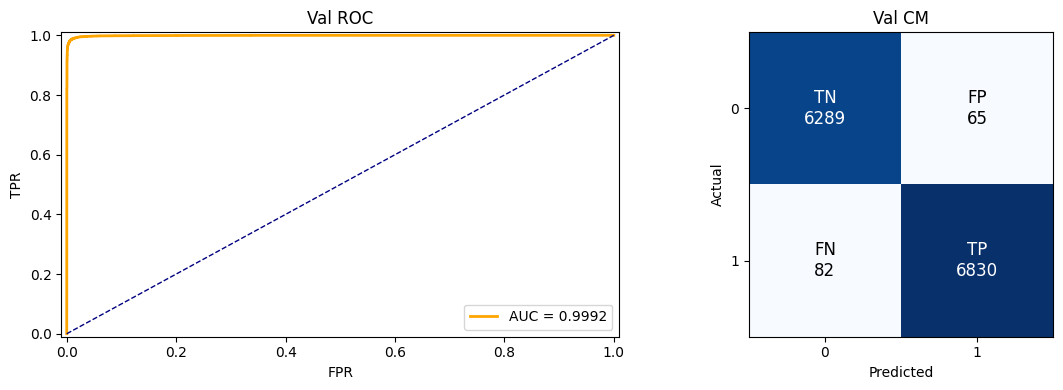

In [9]:
"""Val evaluation (same-distribution sanity check -- same runs as training)."""

y_true = y_val
y_prob = clf.predict_proba(X_val)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc     = auc(fpr, tpr)
cm          = confusion_matrix(y_true, y_pred)

print(f"val accuracy:  {(y_pred == y_true).mean():.4f}")
print(f"val AUC:       {roc_auc:.4f}")
print(f"val confusion:\n{cm}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(fpr, tpr, color="orange", lw=2, label=f"AUC = {roc_auc:.4f}")
ax[0].plot([0, 1], [0, 1], "--", color="navy", lw=1)
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].set_title("Val ROC")
ax[0].legend(loc="lower right"); ax[0].set_xlim(-0.01, 1.01); ax[0].set_ylim(-0.01, 1.01)

ax[1].imshow(cm, cmap="Blues")
ax[1].set_xticks([0, 1]); ax[1].set_yticks([0, 1])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual"); ax[1].set_title("Val CM")
cell_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax[1].text(j, i, f"{cell_labels[i][j]}\n{cm[i,j]}", ha="center", va="center",
                   color="white" if cm[i,j] > cm.max() / 2 else "black", fontsize=12)
plt.tight_layout(); plt.show()


### Per-run holdout evaluation — the real test

Run the trained model on the holdout runs and look at:

1. **Per-run breakdown** — accuracy and mean P(electron) per held-out run. A "good" result here looks like:
   - h holdout runs: low mean P(e) (~0.1–0.3), accuracy ~90%+
   - e holdout runs: high mean P(e) (~0.7–0.9), accuracy ~90%+
2. **Overall holdout ROC / AUC / confusion matrix** — the per-event view across all holdouts combined.
3. **Comparison to val accuracy** — the *gap* between val and holdout is the size of the run-fingerprint shortcut.

Likely outcomes:
- **Holdout matches val (~98%)** → the model learned a generalizable feature. Strong result.
- **Holdout drops moderately (~75–85%)** → mix of real learning and shortcut; the per-run pattern will tell you which is dominant per cell.
- **Holdout collapses to ~50%** → the model was riding run-fingerprint shortcuts. The per-event ~98% was misleading.


per-run holdout results:
    run  part.   bias        n   mean P(e)   accuracy
  -------------------------------------------------------
    577      h     43    17621      0.0218     0.9836
    579      h     45    20390      0.0200     0.9839
    605      e     43    17010      0.9978     0.9984
    603      e     45     3432      0.9665     0.9735

overall holdout accuracy: 0.9874
compare to val accuracy:  0.9889
gap (shortcut size):      +0.0015

holdout AUC: 0.9993
holdout confusion:
[[37393   618]
 [  119 20323]]


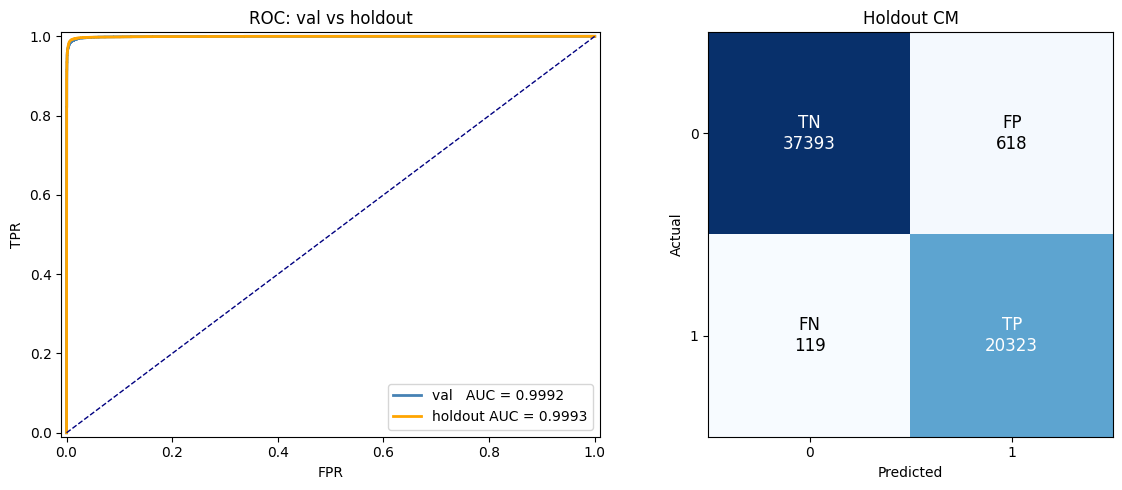

In [10]:
"""Evaluate the trained model on the held-out runs."""

hold_probs = clf.predict_proba(X_hold)[:, 1]
hold_preds = (hold_probs > 0.5).astype(int)
hold_y     = y[holdout_idx]
hold_run   = run_id[holdout_idx]

# Per-run breakdown
print("per-run holdout results:")
print(f"  {'run':>5}  {'part.':>5}  {'bias':>5}  {'n':>7}  {'mean P(e)':>10}  {'accuracy':>9}")
print("  " + "-" * 55)
for rn in HOLDOUT_RUNS:
    m = hold_run == rn
    if not m.any(): continue
    p = particle[holdout_idx[m]][0]
    b = bias_v[holdout_idx[m]][0]
    mean_pe = hold_probs[m].mean()
    acc     = (hold_preds[m] == hold_y[m]).mean()
    print(f"  {rn:>5}  {p:>5}  {b:>5}  {m.sum():>7}  {mean_pe:>10.4f}  {acc:>9.4f}")

acc_overall = (hold_preds == hold_y).mean()
print(f"\noverall holdout accuracy: {acc_overall:.4f}")
print(f"compare to val accuracy:  {(y_pred == y_true).mean():.4f}")
print(f"gap (shortcut size):      {(y_pred == y_true).mean() - acc_overall:+.4f}")

fpr_h, tpr_h, _ = roc_curve(hold_y, hold_probs)
roc_auc_h       = auc(fpr_h, tpr_h)
cm_h            = confusion_matrix(hold_y, hold_preds)

print(f"\nholdout AUC: {roc_auc_h:.4f}")
print(f"holdout confusion:\n{cm_h}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(fpr,   tpr,   color="steelblue", lw=2, label=f"val   AUC = {roc_auc:.4f}")
ax[0].plot(fpr_h, tpr_h, color="orange",    lw=2, label=f"holdout AUC = {roc_auc_h:.4f}")
ax[0].plot([0, 1], [0, 1], "--", color="navy", lw=1)
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[0].set_title("ROC: val vs holdout"); ax[0].legend(loc="lower right")
ax[0].set_xlim(-0.01, 1.01); ax[0].set_ylim(-0.01, 1.01)

ax[1].imshow(cm_h, cmap="Blues")
ax[1].set_xticks([0, 1]); ax[1].set_yticks([0, 1])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual"); ax[1].set_title("Holdout CM")
cell_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax[1].text(j, i, f"{cell_labels[i][j]}\n{cm_h[i,j]}", ha="center", va="center",
                   color="white" if cm_h[i,j] > cm_h.max() / 2 else "black", fontsize=12)
plt.tight_layout(); plt.show()
